[-3.89443668e-02 -3.90479037e-02 -3.91517045e-02 ... -4.74871465e-06
 -4.73560966e-06 -4.72254083e-06]
[-3.89443668e-02 -3.90479037e-02 -3.91517045e-02 ... -4.74871465e-06
 -4.73560966e-06 -4.72254083e-06]


Text(0.5, 0, 'Wavelength (μm)')

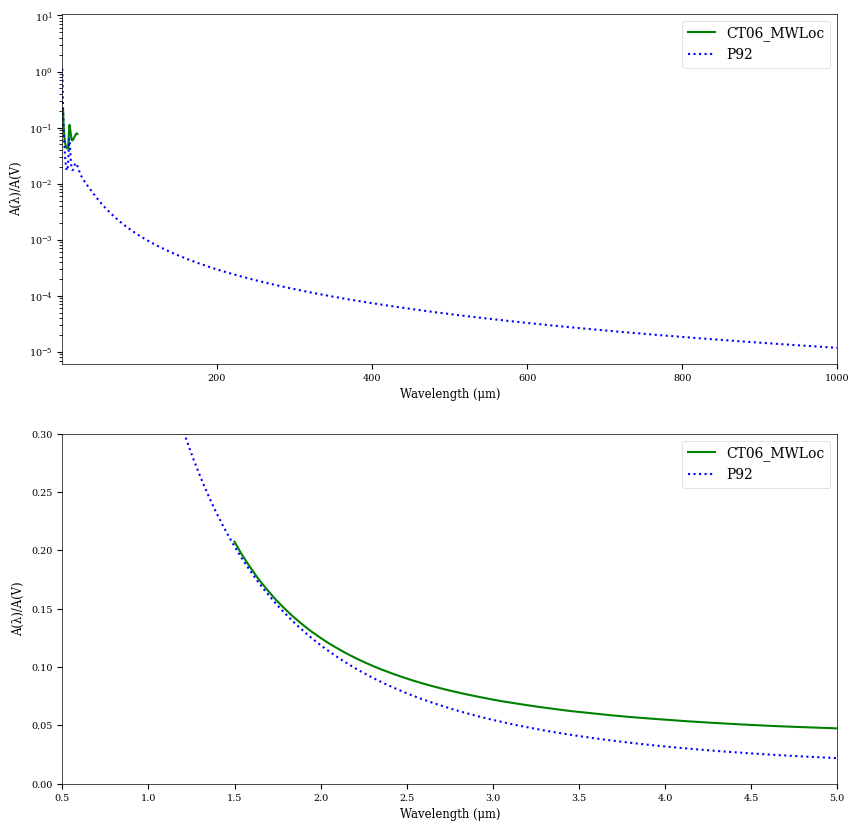

In [5]:
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc, G21_MWAvg,RRP89_MWGC, G24_SMCAvg
from dust_extinction.shapes import P92
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from sedfitter.extinction import Extinction

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(211)
wave_CT06 = np.linspace(1.5, 20, 1000)  # Wavelength range from 0.1 to 3 microns
ext_CT06 = CT06_MWLoc()
ext_P92 = P92()

def make_extinction():
    ext = P92()

    guyver2009_avtocol = (2.21e21 * u.cm**-2 * (1.34 * u.Da)).to(u.g / u.cm**2)
    ext_wav = np.sort((np.geomspace(0.001, 1000, 10000) / u.um).to(u.um, u.spectral()))
    ext_vals = ext(ext_wav)

    extinction = Extinction()
    extinction.wav = ext_wav
    extinction.chi = ext_vals / guyver2009_avtocol
    return extinction


extinction = make_extinction()
ax.plot(wave_CT06, ext_CT06(1/wave_CT06/u.um), label='CT06_MWLoc', color='green')
print(extinction.get_av(extinction.wav))
ax.plot(extinction.wav, extinction.get_av(extinction.wav)/(-0.4), label='P92', color='blue', ls='dotted')
ax.legend()
ax.set_xlim(0.5, 1000)
#ax.set_ylim(0,0.3)
ax.set_yscale('log')
ax.set_ylabel('A(λ)/A(V)')
ax.set_xlabel('Wavelength (μm)')

ax2 = fig.add_subplot(212)
ax2.plot(wave_CT06, ext_CT06(1/wave_CT06/u.um), label='CT06_MWLoc', color='green')
print(extinction.get_av(extinction.wav))
ax2.plot(extinction.wav, extinction.get_av(extinction.wav)/(-0.4), label='P92', color='blue', ls='dotted')
ax2.legend()
ax2.set_xlim(0.5, 5)
ax2.set_ylim(0,0.3)
ax2.set_ylabel('A(λ)/A(V)')
ax2.set_xlabel('Wavelength (μm)')


(0.0, 0.5)

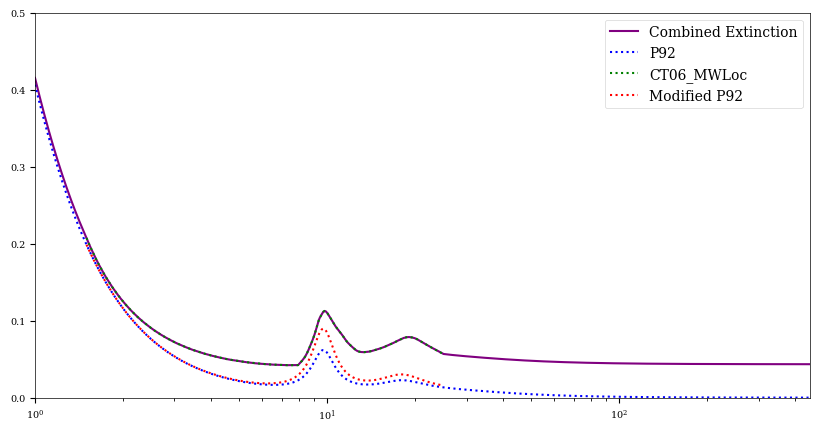

In [6]:
ext_p92 = P92()
ext_ct06 = CT06_MWLoc()
guyver2009_avtocol = (2.21e21 * u.cm**-2 * (1.34 * u.Da)).to(u.g / u.cm**2)
ext_wav = np.sort((np.geomspace(0.001, 1000, 10000) / u.um).to(u.um, u.spectral()))
wav_ct06 = np.linspace(1.5, 25, 1000)*u.um  # Wavelength range from 0.1 to 3 microns
ext_val_p92 = ext_p92(ext_wav)
ext_val_ct06 = ext_ct06(wav_ct06)

idx_short = np.where(ext_wav<1.5*u.um)[0]
idx_mid = np.where((ext_wav>=1.5*u.um) & (ext_wav<=25*u.um))[0]
idx_long = np.where(ext_wav>25*u.um)[0]

ext_vals = np.zeros_like(ext_wav.value)
if ext_val_p92[idx_mid[0]] > ext_val_ct06[0]:
    diff = ext_val_p92[idx_mid[0]] - ext_val_ct06[0]
    ext_vals[idx_short] = ext_val_p92[idx_short] - diff
else:
    diff = ext_val_ct06[0] - ext_val_p92[idx_mid[0]]
    ext_vals[idx_short] = ext_val_p92[idx_short] + diff
ext_vals[idx_mid] = ext_ct06(ext_wav[idx_mid])
if ext_val_p92[idx_mid[-1]] > ext_val_ct06[-1]:
    diff = ext_val_p92[idx_mid[-1]] - ext_val_ct06[-1]
    ext_vals[idx_long] = ext_val_p92[idx_long] - diff
else:
    diff = ext_val_ct06[-1] - ext_val_p92[idx_mid[-1]]
    ext_vals[idx_long] = ext_val_p92[idx_long] + diff
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111)
ax.plot(ext_wav, ext_vals, label='Combined Extinction', color='purple')
ax.plot(ext_wav, ext_val_p92, label='P92', color='blue', ls='dotted')
ax.plot(wav_ct06, ext_val_ct06, label='CT06_MWLoc', color='green', ls='dotted')

modified_p92 = P92(SIL1_amp=0.004, SIL2_amp=0.004)
ax.plot(wav_ct06, modified_p92(wav_ct06), label='Modified P92', color='red', ls='dotted')

ax.legend()
ax.set_xscale('log')
ax.set_xlim(1,450)
ax.set_ylim(0,0.5)

Initial parameters:
BKG_amp = 280
BKG_lambda = 0.047
BKG_b = 90
BKG_n = 2
SIL1_amp = 0.00264935
SIL1_lambda = 9.7
SIL1_b = -1.95
SIL1_n = 2
SIL2_amp = 0.004
SIL2_lambda = 18
SIL2_b = -1.8
SIL2_n = 2
Best-fit parameters:
BKG_amp = 250
BKG_lambda = 0.02
BKG_b = 407.27
BKG_n = 1.5907
SIL1_amp = 0.00194345
SIL1_lambda = 9.8
SIL1_b = -1.97467
SIL1_n = 1.5
SIL2_amp = 0.0346621
SIL2_lambda = 18.6
SIL2_b = -1.43583
SIL2_n = 1.5
Cost = 0.351227
Success = True
Message = `ftol` termination condition is satisfied.


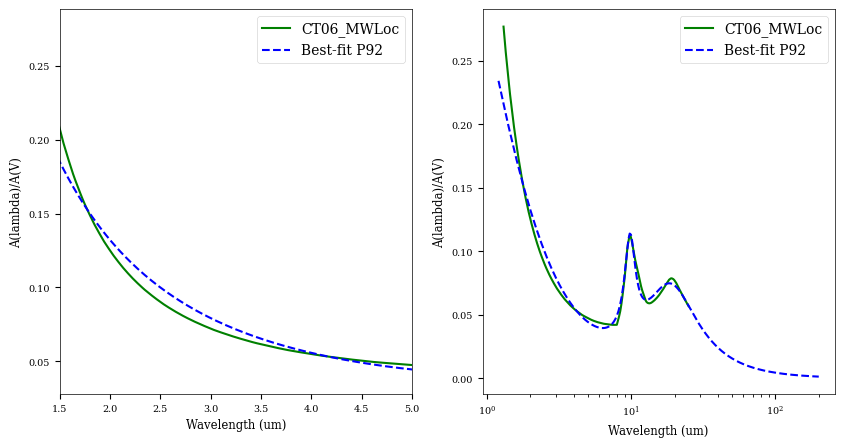

In [7]:
from scipy.optimize import least_squares
import numpy as np
import astropy.units as u
from dust_extinction.averages import CT06_MWLoc
from dust_extinction.shapes import P92

wave_CT06 = np.linspace(1.3, 25, 1000) * u.um
x_CT06 = (1.0 / wave_CT06).to(1 / u.um)

ext_CT06 = CT06_MWLoc()
target = ext_CT06(x_CT06)

free_names = [ "BKG_amp","BKG_lambda","BKG_b", "BKG_n", 
"SIL1_amp", "SIL1_lambda", "SIL1_b", "SIL1_n", 
"SIL2_amp", "SIL2_lambda", "SIL2_b", "SIL2_n"]

base = P92()
fixed_params = {name: getattr(base, name).value for name in base.param_names}
for name in free_names:
    fixed_params.pop(name, None)

def build_params(theta):
    params = dict(fixed_params)
    params.update({name: value for name, value in zip(free_names, theta)})
    return params

def p92_curve(params, wave_um):
    model = P92(**params)
    wave_um = u.Quantity(wave_um, u.um)
    x = (1.0 / wave_um).to(1 / u.um)
    return model(x)

x0 = np.array([getattr(base, name).value for name in free_names], dtype=float)
x0[0] = 280
x0[8] = 0.004
print("Initial parameters:")
for name, value in zip(free_names, x0):
    print(f"{name} = {value:.6g}")

lower = np.array( [250,  0.02, 50, 1.5,
                  0.001, 9.6, -3, 1.5,
                  0.001, 17.9, -3, 1.5])
upper = np.array([800, 0.06, 500, 2.5,
                  0.004, 9.8, -1, 2.5,
                  0.5, 18.6, -1, 2.5    ])

def residuals(theta):
    model = p92_curve(build_params(theta), wave_CT06)
    return np.log10(model) - np.log10(target)

result = least_squares(residuals, x0=x0, bounds=(lower, upper))
best_params = build_params(result.x)
best_curve = p92_curve(best_params, wave_CT06)

print("Best-fit parameters:")
for name in free_names:
    print(f"{name} = {best_params[name]:.6g}")

print(f"Cost = {result.cost:.6g}")
print(f"Success = {result.success}")
print(f"Message = {result.message}")

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(121)
ax.plot(wave_CT06.value, target, color="green", label="CT06_MWLoc")
ax.plot(wave_CT06.value, best_curve, color="blue", ls="--", label="Best-fit P92")
ax.set_xlim(1.5, 5.0)
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("A(lambda)/A(V)")
ax.legend()

wav_p92 = np.linspace(1.2, 200, 1000)*u.um
ax2 = fig.add_subplot(122)
ax2.plot(wave_CT06.value, target, color="green", label="CT06_MWLoc")
ax2.plot(wav_p92, p92_curve(best_params, wav_p92), color="blue", ls="--", label="Best-fit P92")
#ax2.plot(wav_p92, P92(1/wav_p92), color="orange", ls=":", label="Default P92")
ax2.set_xlabel("Wavelength (um)")
ax2.set_ylabel("A(lambda)/A(V)")
ax2.legend()


ax2.set_xscale('log')
plt.show()


(0.0, 0.4)

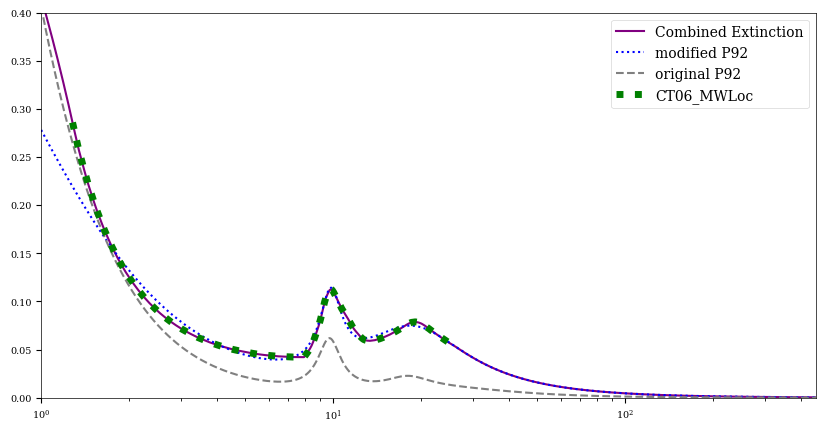

In [12]:
ext_p92_original = P92()
ext_p92 = P92(**best_params)
ext_ct06 = CT06_MWLoc()
guyver2009_avtocol = (2.21e21 * u.cm**-2 * (1.34 * u.Da)).to(u.g / u.cm**2)
ext_wav = np.sort((np.geomspace(0.001, 1000, 10000) / u.um).to(u.um, u.spectral()))
wav_ct06 = np.geomspace(1.28, 25, 1000)*u.um  # Wavelength range from 0.1 to 3 microns
ext_val_p92 = ext_p92(ext_wav)
ext_val_p92_original = ext_p92_original(ext_wav)
ext_val_ct06 = ext_ct06(wav_ct06)
wav_short = np.where(ext_wav<1.28*u.um)[0]
wav_mid = np.where((ext_wav>=1.28*u.um) & (ext_wav<=26.5*u.um))[0]
wav_long = np.where(ext_wav>26.5*u.um)[0]

ext_val = np.zeros_like(ext_wav.value)
ext_val[wav_mid] = ext_ct06((1.0 / ext_wav[wav_mid]).to(1 / u.um))
slope = (ext_val[wav_mid][0] - ext_val[wav_mid][1]) / (ext_wav[wav_mid][0].value - ext_wav[wav_mid][1].value)
intercept = ext_val_ct06[0] - slope * wav_ct06[0].value

ext_val[wav_short] = slope * ext_wav[wav_short].value + intercept
ext_val[wav_long] = ext_val_p92[wav_long]
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111)
ax.plot(ext_wav, ext_val, label='Combined Extinction', color='purple')
ax.plot(ext_wav, ext_val_p92, label='modified P92', color='blue', ls='dotted')
ax.plot(ext_wav, ext_val_p92_original, label='original P92', color='gray', ls='dashed')
ax.plot(wav_ct06, ext_val_ct06, label='CT06_MWLoc', color='green', ls='dotted', lw=5)
ax.legend()
ax.set_xscale('log')
ax.set_xlim(1,450)
ax.set_ylim(0,0.4)
